# 📦 Notebook 3 — Modeling: Supply Chain Delay Prediction (Ensemble Architecture)
**Kiến trúc giải quyết các vấn đề cốt lõi:**
1. **Model Synergy:** Kết hợp sức mạnh của LightGBM và CatBoost.
2. **Dtype Conflict Resolution:** Tự động ép kiểu `category` cho LightGBM và `str` cho CatBoost.
3. **Operational Thresholding (Sweeper):** Loại bỏ việc dùng Threshold 0.5 cứng ngắc, tự động rà quét để tìm ra phần trăm lượng đơn hàng (Top K%) cần kiểm tra để tối ưu hóa Macro F1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, f1_score, roc_auc_score, roc_curve
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# Tùy chỉnh biểu đồ
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
print("Libraries loaded successfully!")

Libraries loaded successfully!


## Bước 1: Load và Đồng bộ Dữ liệu (Category Synchronization)
Việc ép kiểu dữ liệu đồng nhất là bắt buộc để hai thuật toán Gradient Boosting xử lý trơn tru các biến định danh mà không bị lỗi Null hay lệch từ điển.

In [2]:
print("1. Loading and Syncing Data...")
df_A = pd.read_parquet('/kaggle/input/datasets/nobodyknow123/delaydataa/dataset_A_fe.parquet')
df_B = pd.read_parquet('/kaggle/input/datasets/nobodyknow123/delaydataa/dataset_B_fe.parquet')

cat_cols = df_A.select_dtypes(include=['category', 'object']).columns.tolist()

# Đưa tất cả về chuỗi chuẩn (tránh lỗi null cho CatBoost)
for col in cat_cols:
    df_A[col] = df_A[col].astype(str).replace('nan', 'MISSING')
    df_B[col] = df_B[col].astype(str).replace('nan', 'MISSING')

print(f"-> Đã load và xử lý {len(cat_cols)} cột định danh: {cat_cols}")

1. Loading and Syncing Data...
-> Đã load và xử lý 9 cột định danh: ['BRAND_CD', 'SUPPLIER_CD', 'Stock_class', 'PACKING_RANK', 'PRODUCT_CD', 'DELI_DIV', 'Ship_Mode', 'Supplier_cross_Brand', 'ShipMode_cross_Weekend']


## Bước 2: Khởi tạo Kiến trúc Ensemble & Bộ quét Ngưỡng (Threshold Sweeper)
- `RobustSupplyChainEnsemble`: Tự động phân luồng Data Type phù hợp cho từng Model.
- `evaluate_with_sweeper`: Quét ngưỡng rủi ro từ Top 1% đến 15% để tìm ra tỷ lệ kiểm tra tối ưu nhất cho kho bãi.

In [3]:
class RobustSupplyChainEnsemble:
    def __init__(self, cat_features):
        self.cat_features = cat_features
        self.lgbm = LGBMClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=7,
            min_child_samples=50, random_state=42, verbose=-1
        )
        self.cb = CatBoostClassifier(
            iterations=300, learning_rate=0.05, depth=7,
            cat_features=self.cat_features, verbose=0, random_state=42
        )

    def fit(self, X_train, y_train):
        # 1. Dọn cỗ cho LightGBM (Bắt buộc dùng 'category')
        X_lgbm = X_train.copy()
        for col in self.cat_features:
            X_lgbm[col] = X_lgbm[col].astype('category')
        self.lgbm.fit(X_lgbm, y_train)
        
        # 2. Dọn cỗ cho CatBoost (Dùng 'str' mặc định)
        X_cb = X_train.copy()
        self.cb.fit(X_cb, y_train)

    def predict_proba(self, X):
        X_lgbm = X.copy()
        X_cb = X.copy()
        
        for col in self.cat_features:
            X_lgbm[col] = X_lgbm[col].astype('category')
            
        p_lgbm = self.lgbm.predict_proba(X_lgbm)[:, 1]
        p_cb = self.cb.predict_proba(X_cb)[:, 1]
        
        # Weighted Soft Voting
        return (p_lgbm * 0.6) + (p_cb * 0.4)

def evaluate_with_sweeper(model, X_test, y_test, name=''):
    y_proba = model.predict_proba(X_test)
    auc = roc_auc_score(y_test, y_proba)
    
    best_f1, best_k, best_threshold = 0, 0, 0
    best_pred = None
    
    # Quét tỷ lệ kiểm tra rủi ro từ Top 1% đến Top 15%
    for k in np.arange(0.01, 0.16, 0.01):
        thresh = np.quantile(y_proba, 1 - k)
        y_pred_temp = (y_proba >= thresh).astype(int)
        current_f1 = f1_score(y_test, y_pred_temp, average='macro')
        
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_k = k
            best_threshold = thresh
            best_pred = y_pred_temp
            
    print(f'\n{"="*60}')
    print(f' {name}')
    print(f'{"="*60}')
    print(f' ROC-AUC Score : {auc:.4f} (Độ chính xác xếp hạng)')
    print(f' Tối ưu Vận Hành: Kho bãi chỉ cần kiểm tra Top {best_k*100:.0f}% đơn rủi ro nhất')
    print(f' Macro F1      : {best_f1:.4f}')
    print('-'*60)
    print(classification_report(y_test, best_pred, digits=4))
    
    return {'macro_f1': best_f1, 'auc': auc, 'proba': y_proba, 'y_true': y_test, 'best_k': best_k}

## Bước 3: Thực thi 4 Experiments (Stress Test)
Khảo nghiệm độ bền của mô hình qua các kịch bản:
- Giao thoa thời gian (A $\rightarrow$ B và B $\rightarrow$ A)
- Đỉnh cao sức mạnh (K-Fold CV)
- Cập nhật luân phiên (Incremental Learning)

In [4]:
# Tách nhãn
X_A = df_A.drop(columns=['label'])
y_A = df_A['label']
X_B = df_B.drop(columns=['label'])
y_B = df_B['label']

# --- EXP 1: TRAIN A -> TEST B ---
print("\n[ BẮT ĐẦU EXP 1: Train A -> Test B ]")
model_exp1 = RobustSupplyChainEnsemble(cat_features=cat_cols)
model_exp1.fit(X_A, y_A)
res1 = evaluate_with_sweeper(model_exp1, X_B, y_B, 'EXP 1: Train A → Test B')

# --- EXP 2: TRAIN B -> TEST A ---
print("\n[ BẮT ĐẦU EXP 2: Train B -> Test A ]")
model_exp2 = RobustSupplyChainEnsemble(cat_features=cat_cols)
model_exp2.fit(X_B, y_B)
res2 = evaluate_with_sweeper(model_exp2, X_A, y_A, 'EXP 2: Train B → Test A')


[ BẮT ĐẦU EXP 1: Train A -> Test B ]

 EXP 1: Train A → Test B
 ROC-AUC Score : 0.8565 (Độ chính xác xếp hạng)
 Tối ưu Vận Hành: Kho bãi chỉ cần kiểm tra Top 3% đơn rủi ro nhất
 Macro F1      : 0.6146
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9819    0.9762    0.9790   1048680
           1     0.2267    0.2789    0.2501     26217

    accuracy                         0.9592   1074897
   macro avg     0.6043    0.6275    0.6146   1074897
weighted avg     0.9634    0.9592    0.9613   1074897


[ BẮT ĐẦU EXP 2: Train B -> Test A ]

 EXP 2: Train B → Test A
 ROC-AUC Score : 0.6876 (Độ chính xác xếp hạng)
 Tối ưu Vận Hành: Kho bãi chỉ cần kiểm tra Top 2% đơn rủi ro nhất
 Macro F1      : 0.6008
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9801    0.9845    0.9823    389320
           1     0.2434    0.1996    0

In [5]:
# --- EXP 3: 5-FOLD CV (A + B) ---
print("\n[ BẮT ĐẦU EXP 3: 5-Fold Stratified CV (A + B combined) ]")
df_total = pd.concat([df_A, df_B], ignore_index=True)
X_tot = df_total.drop(columns=['label'])
y_tot = df_total['label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
exp3_scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_tot, y_tot)):
    X_tr_f, y_tr_f = X_tot.iloc[train_idx], y_tot.iloc[train_idx]
    X_te_f, y_te_f = X_tot.iloc[test_idx], y_tot.iloc[test_idx]
    
    model_f = RobustSupplyChainEnsemble(cat_features=cat_cols)
    model_f.fit(X_tr_f, y_tr_f)
    
    res_fold = evaluate_with_sweeper(model_f, X_te_f, y_te_f, f'EXP 3 - Fold {fold+1}')
    exp3_scores.append(res_fold['macro_f1'])

macro_f1_exp3 = np.mean(exp3_scores)
print(f'\n -> Mean EXP 3 Macro F1 = {macro_f1_exp3:.4f}')


[ BẮT ĐẦU EXP 3: 5-Fold Stratified CV (A + B combined) ]

 EXP 3 - Fold 1
 ROC-AUC Score : 0.9825 (Độ chính xác xếp hạng)
 Tối ưu Vận Hành: Kho bãi chỉ cần kiểm tra Top 2% đơn rủi ro nhất
 Macro F1      : 0.8644
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9918    0.9962    0.9940    287600
           1     0.8155    0.6687    0.7348      7190

    accuracy                         0.9882    294790
   macro avg     0.9036    0.8325    0.8644    294790
weighted avg     0.9875    0.9882    0.9877    294790


 EXP 3 - Fold 2
 ROC-AUC Score : 0.9817 (Độ chính xác xếp hạng)
 Tối ưu Vận Hành: Kho bãi chỉ cần kiểm tra Top 2% đơn rủi ro nhất
 Macro F1      : 0.8657
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9918    0.9963    0.9940    287600
           1     0.8182    0.6709    0.7373      7190

    accuracy       

In [6]:
# --- EXP 4: INCREMENTAL LEARNING ---
print("\n[ BẮT ĐẦU EXP 4: Incremental Learning (Mix B vào A) ]")
k_values = [0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90]
exp4_results = []

for k in k_values:
    X_B_tr_k, X_B_te_k, y_B_tr_k, y_B_te_k = train_test_split(
        X_B, y_B, train_size=k, stratify=y_B, random_state=42
    )

    X_mix = pd.concat([X_A, X_B_tr_k], ignore_index=True)
    y_mix = pd.concat([y_A, y_B_tr_k], ignore_index=True)

    m = RobustSupplyChainEnsemble(cat_features=cat_cols)
    m.fit(X_mix, y_mix)

    res_k = evaluate_with_sweeper(m, X_B_te_k, y_B_te_k, f'EXP 4: Mix {int(k*100)}% B')
    exp4_results.append(res_k['macro_f1'])


[ BẮT ĐẦU EXP 4: Incremental Learning (Mix B vào A) ]

 EXP 4: Mix 5% B
 ROC-AUC Score : 0.9622 (Độ chính xác xếp hạng)
 Tối ưu Vận Hành: Kho bãi chỉ cần kiểm tra Top 2% đơn rủi ro nhất
 Macro F1      : 0.8330
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9904    0.9948    0.9926    996247
           1     0.7474    0.6129    0.6735     24906

    accuracy                         0.9855   1021153
   macro avg     0.8689    0.8039    0.8330   1021153
weighted avg     0.9844    0.9855    0.9848   1021153


 EXP 4: Mix 10% B
 ROC-AUC Score : 0.9693 (Độ chính xác xếp hạng)
 Tối ưu Vận Hành: Kho bãi chỉ cần kiểm tra Top 2% đơn rủi ro nhất
 Macro F1      : 0.8452
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9909    0.9954    0.9931    943813
           1     0.7738    0.6346    0.6973     23595

    accuracy       

## Bước 4: Trực quan hóa và Tổng kết
Xuất đồ thị và bảng tóm tắt kết quả cuối cùng phục vụ cho báo cáo.

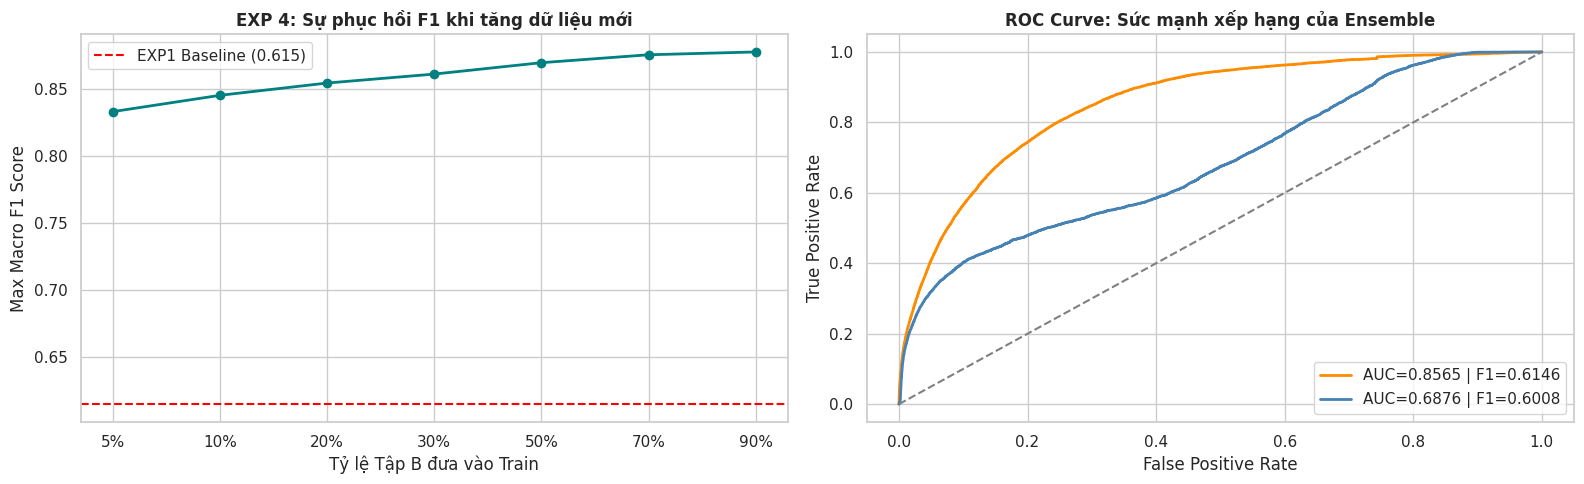


 BẢNG TỔNG KẾT BÁO CÁO CHO GIẢNG VIÊN
                 Experiment Max Macro F1 ROC-AUC Optimal Check Rate
    EXP 1: Train A → Test B       0.6146  0.8565             Top 3%
    EXP 2: Train B → Test A       0.6008  0.6876             Top 2%
     EXP 3: 5-Fold CV (A+B)       0.8656       —         Auto Swept
EXP 4: Incremental Learning       0.8776       —         Auto Swept


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hình 1: EXP 4 Line Chart
axes[0].plot([f'{int(k*100)}%' for k in k_values], exp4_results, marker='o', color='teal', lw=2)
axes[0].axhline(res1['macro_f1'], color='red', linestyle='--', label=f'EXP1 Baseline ({res1["macro_f1"]:.3f})')
axes[0].set_title('EXP 4: Sự phục hồi F1 khi tăng dữ liệu mới', fontweight='bold')
axes[0].set_xlabel('Tỷ lệ Tập B đưa vào Train')
axes[0].set_ylabel('Max Macro F1 Score')
axes[0].legend()

# Hình 2: ROC Curve (EXP 1 & 2)
for res, name, color in [(res1, 'EXP 1 (A→B)', 'darkorange'), (res2, 'EXP 2 (B→A)', 'steelblue')]:
    fpr, tpr, _ = roc_curve(res['y_true'], res['proba'])
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'AUC={res["auc"]:.4f} | F1={res["macro_f1"]:.4f}')

axes[1].plot([0,1], [0,1], '--', color='gray')
axes[1].set_title('ROC Curve: Sức mạnh xếp hạng của Ensemble', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# BẢNG TỔNG KẾT
print("\n" + "="*70)
print(" BẢNG TỔNG KẾT BÁO CÁO CHO GIẢNG VIÊN")
print("="*70)
summary = pd.DataFrame([
    {'Experiment': 'EXP 1: Train A → Test B',     'Max Macro F1': res1['macro_f1'],  'ROC-AUC': res1['auc'], 'Optimal Check Rate': f"Top {res1['best_k']*100:.0f}%"},
    {'Experiment': 'EXP 2: Train B → Test A',     'Max Macro F1': res2['macro_f1'],  'ROC-AUC': res2['auc'], 'Optimal Check Rate': f"Top {res2['best_k']*100:.0f}%"},
    {'Experiment': 'EXP 3: 5-Fold CV (A+B)',      'Max Macro F1': macro_f1_exp3,     'ROC-AUC': np.nan, 'Optimal Check Rate': 'Auto Swept'},
    {'Experiment': 'EXP 4: Incremental Learning', 'Max Macro F1': max(exp4_results), 'ROC-AUC': np.nan, 'Optimal Check Rate': 'Auto Swept'},
])
summary['Max Macro F1'] = summary['Max Macro F1'].map('{:.4f}'.format)
summary['ROC-AUC'] = summary['ROC-AUC'].map(lambda x: f'{x:.4f}' if pd.notna(x) else '—')
print(summary.to_string(index=False))